# #1 Define gene programs

## Purpose

This notebook defines gene programs using the Hotspot algorithm.

## Setup

In [ ]:
from pathlib import Path
import treedata as td
import pycea as py
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
from scipy import sparse
import scipy as sp
import hotspot

from devmap.config import set_theme, get_paths
from devmap.utils import load_data
from devmap.gene_programs import create_knn_graph, get_clusters, score_programs
from devmap.gene_programs import compute_modules_agglomerative

set_theme()
base_path, plots_path, results_path = get_paths("gene_programs")

## Load data

In [ ]:
tdata = load_data("log1p_hvg")

## Get gene stats

In [ ]:
subset = tdata[tdata.obs.query("clone.notnull()").groupby("stage").head(50000).index,:].copy()
py.tl.tree_neighbors(subset, n_neighbors=5, depth_key="time", update = False)
neighbors, weights = create_knn_graph(subset.obsp["tree_distances"], subset.obs_names, sigma=2.0)
umi_counts = pd.Series(np.asarray(subset.X.sum(axis = 1)).ravel(), index=subset.obs_names)

In [50]:
gene_stats = hotspot.local_stats.compute_hs(subset.X.transpose(), neighbors, weights, umi_counts, model = "normal", jobs=30, genes = subset.var_names)

100%|██████████| 5000/5000 [32:24<00:00,  2.57it/s]


In [ ]:
gene_stats.to_csv(results_path / "gene_autocorrelation.csv")

## Local autocorrelation

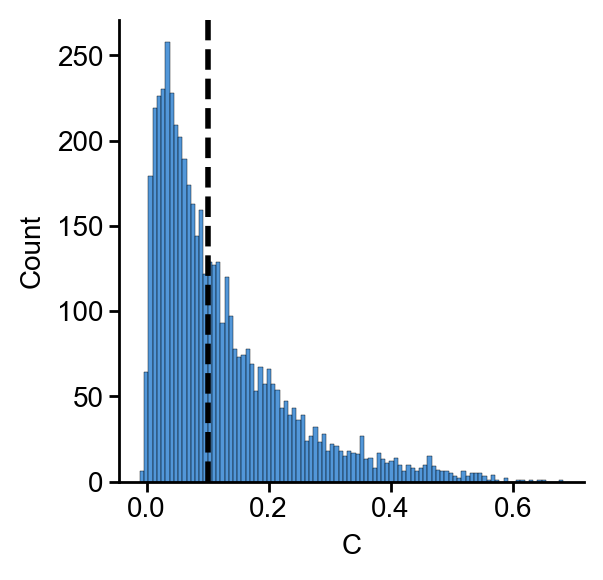

In [62]:
threshold = .1
sns.histplot(gene_stats["C"], bins=100)
plt.axvline(threshold, color="black", linestyle="--")
use_genes = gene_stats.query("C > @threshold").index

In [64]:
counts = pd.DataFrame(subset[:, use_genes].X.transpose().toarray(), index=use_genes, columns=subset.obs_names)
LC, LZ = hotspot.local_stats_pairs.compute_hs_pairs_centered_cond(
    counts,
    neighbors,
    weights,
    umi_counts,
    model = "normal",
    jobs = 30
)

100%|██████████| 2480878/2480878 [23:18<00:00, 1773.97it/s]


In [66]:
LZ.to_csv(results_path / "local_correlations_z.csv")
LC.to_csv(results_path / "local_correlations.csv")

## Get programs

In [ ]:
clusters, linkage = get_clusters(LZ, t = 8)
hotspot.plots.local_correlation_plot(LZ, clusters, linkage = linkage, vmin=-50, vmax=100)

In [ ]:
programs = []
for c in clusters.unique():
    cluster_Z = LZ.loc[clusters == c, clusters == c]
    cluster_programs, _ = compute_modules_agglomerative(
        cluster_Z,
        min_gene_threshold=4,
        z_threshold=80,
    )
    _, linkage = hotspot.modules.compute_modules(cluster_Z, min_gene_threshold=8, core_only=True,z_threshold=40)
    hotspot.plots.local_correlation_plot(cluster_Z, cluster_programs, linkage = linkage, vmin=-50, vmax=200)
    #cluster_programs, linkage = hotspot.modules.compute_modules(cluster_Z, min_gene_threshold=8, core_only=True,z_threshold=40)
    programs.append(cluster_programs.to_frame().assign(Cluster=c))  
programs = pd.concat(programs)

## Score cells

In [ ]:
programs = programs.query("Module != -1").reset_index().groupby(["Cluster","Module"]).agg(
    {"Gene": lambda x: ", ".join(x)}).reset_index()
programs["program"] = "P" + (np.arange(len(programs)) + 1).astype(str)
programs["genes"]= programs["Gene"]
programs = programs[["program", "genes"]]

In [ ]:
program_scores = score_programs(
    tdata,
    programs,
    genes_col="genes",
    program_col="program",
    n_bins=25,
)
program_scores.round(3).to_csv(results_path / "program_scores.csv")

Scoring programs...


## Get cell type activation

In [ ]:
program_scores["cell_type"] = tdata.obs["cell_type"]
mean_scores = program_scores.groupby("cell_type").mean()
program_activation =(mean_scores / mean_scores.max()) > .5
sns.clustermap(mean_scores, cmap="RdBu_r", center=0, vmax = 1, vmin = -.5,xticklabels=mean_scores.columns, yticklabels=mean_scores.index, figsize=(15,15))

In [ ]:
programs["active_in"] = program_activation.T.apply(lambda row: ", ".join(row.index[row]), axis=1).values
programs.to_csv(results_path / "gene_programs.csv", index=False)

## Get cell type activation by stage

In [ ]:
program_scores["stage"] = tdata.obs["stage"]
mean_scores = program_scores.groupby(["cell_type", "stage"], observed = True).mean().reset_index()
mean_scores.round(3).to_csv(results_path / "program_scores_by_stage.csv")